# Data Overview and Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/raw_data.xlsx')

df.head()


,SKU_ID,Category,ABC_Class,Supplier_Name,Warehouse_Location,Received_Date,Last_Purchase_Date,Stock_Age_Days,Quantity_On_Hand,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d,Reorder_Point,Safety_Stock,Lead_Time_Days,Total_Inventory_Value_USD,Supplier_OnTime_Pct,Inventory_Status
0,SKU_14996,Household,A,NextGen Traders,Chennai Warehouse,2024-06-11,2024-07-11,212,482.0,13,9,19.84,459.32,126,47,7.0,45555.63,82.64,Normal
1,SKU_10247,Snacks,C,NextGen Traders,Bangalore Warehouse,2024-11-24,2025-03-19,357,640.0,8,6,34.81,1072.54,110,75,5.0,36577.48,94.58,Normal
2,SKU_16215,Dairy,C,NextGen Traders,Chennai Warehouse,2023-02-01,2023-03-06,104,538.0,5,3,49.66,1891.81,118,66,12.0,23742.67,98.22,Overstock
3,SKU_13545,Bakery,A,Prime Distribution,Chennai Warehouse,2024-03-13,2024-06-04,161,530.0,9,2,20.00,662.42,119,11,8.0,49287.57,97.45,Low Stock
4,SKU_15397,Produce,B,Global Retail Supply,Chennai Warehouse,2023-05-01,2023-05-09,289,397.0,14,3,32.63,1115.41,128,42,3.0,16929.86,86.75,Overstock


## Data Type Inspection

In [2]:
df.dtypes

SKU_ID                                  str
Category                                str
ABC_Class                               str
Supplier_Name                           str
Warehouse_Location                      str
Received_Date                datetime64[us]
Last_Purchase_Date           datetime64[us]
Stock_Age_Days                        int64
Quantity_On_Hand                    float64
Damaged_Qty                           int64
Returns_Qty                           int64
Avg_Daily_Sales                     float64
Forecast_Next_30d                   float64
Reorder_Point                         int64
Safety_Stock                          int64
Lead_Time_Days                      float64
Total_Inventory_Value_USD           float64
Supplier_OnTime_Pct                 float64
Inventory_Status                        str
dtype: object

### Checking If There Any Duplicates And Removing It

In [3]:
df.duplicated().sum()

np.int64(12)

In [4]:
df = df.drop_duplicates()

In [5]:
df.duplicated().sum()

np.int64(0)

## Missing Value Analysis Treatment

In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Received_Date          201
Forecast_Next_30d      201
Lead_Time_Days         201
Supplier_OnTime_Pct    201
dtype: int64

In [7]:
df[['Avg_Daily_Sales', 'Forecast_Next_30d']].corr()

,Avg_Daily_Sales,Forecast_Next_30d
Avg_Daily_Sales,1.000000,0.823191
Forecast_Next_30d,0.823191,1.000000


In [8]:
ratio = (
    df['Forecast_Next_30d'] /
    df['Avg_Daily_Sales']
).median()

ratio

np.float64(29.83171206225681)

In [9]:
df.loc[df['Forecast_Next_30d'].isnull(),
       'Forecast_Next_30d'] = (
    df['Avg_Daily_Sales'] * ratio
)

In [10]:
df['Lead_Time_Days'] = (
    df.groupby('Supplier_Name')['Lead_Time_Days']
      .transform(lambda x: x.fillna(x.median()))
)

In [11]:
df['Supplier_OnTime_Pct'] = (
    df.groupby('Supplier_Name')['Supplier_OnTime_Pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [12]:
df[df['Received_Date'].isnull()]['Category'].value_counts()

Category
Produce          31
Snacks           30
Bakery           27
Frozen Foods     27
Household        25
Dairy            22
Personal Care    21
Beverages        18
Name: count, dtype: int64

In [13]:
df['Received_Date'] = (
    df.groupby('Category')['Received_Date']
      .transform(lambda x: x.fillna(x.median()))
)

In [14]:
df['Received_Date'].isnull().sum()

np.int64(0)

In [15]:
df.isnull().sum()

SKU_ID                       0
Category                     0
ABC_Class                    0
Supplier_Name                0
Warehouse_Location           0
Received_Date                0
Last_Purchase_Date           0
Stock_Age_Days               0
Quantity_On_Hand             0
Damaged_Qty                  0
Returns_Qty                  0
Avg_Daily_Sales              0
Forecast_Next_30d            0
Reorder_Point                0
Safety_Stock                 0
Lead_Time_Days               0
Total_Inventory_Value_USD    0
Supplier_OnTime_Pct          0
Inventory_Status             0
dtype: int64

### Summary

The dataset contained missing values in four columns: `Received_Date`, `Forecast_Next_30d`, `Lead_Time_Days`, and `Supplier_OnTime_Pct`.

To preserve the underlying business logic of the data:

- `Forecast_Next_30d` was imputed using the relationship between forecast demand and average daily sales. A strong positive correlation (0.823) was observed between the two variables, and the median forecast-to-sales ratio (~29.83) was used to estimate missing values.
- `Lead_Time_Days` was imputed using supplier-wise median values to retain supplier-specific delivery characteristics.
- `Supplier_OnTime_Pct` was imputed using supplier-wise median values to preserve supplier performance patterns.
- Missing values in `Received_Date` were distributed across multiple product categories. Therefore, category-wise median dates were used for imputation to maintain realistic inventory timelines within each category.

After applying these treatments, all missing values were successfully resolved, resulting in a complete dataset for further analysis.

## Categorical Data Standardization

In [16]:
cat_cols = [
    'Category',
    'ABC_Class',
    'Supplier_Name',
    'Warehouse_Location',
    'Inventory_Status'
]

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


Category
<StringArray>
[    'Household',        'Snacks',         'Dairy',        'Bakery',
       'Produce',     'Beverages',  'Frozen Foods', 'Personal Care']
Length: 8, dtype: str

ABC_Class
<StringArray>
['A', 'C', 'B']
Length: 3, dtype: str

Supplier_Name
<StringArray>
[     'NextGen Traders',   'Prime Distribution', 'Global Retail Supply',
  'FreshMart Suppliers',      'Metro Supply Co',      'Urban Wholesale']
Length: 6, dtype: str

Warehouse_Location
<StringArray>
[  'Chennai Warehouse', 'Bangalore Warehouse',    'Mumbai Warehouse',
     'Delhi Warehouse',   'Kolkata Warehouse']
Length: 5, dtype: str

Inventory_Status
<StringArray>
['Normal', 'Overstock', 'Low Stock', 'Critical']
Length: 4, dtype: str


In [17]:
for col in cat_cols:
    df[col] = df[col].str.strip()

In [18]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()}")

Category: 8
ABC_Class: 3
Supplier_Name: 6
Warehouse_Location: 5
Inventory_Status: 4


### Summary

Unique values of categorical columns were reviewed to identify inconsistencies such as extra spaces, spelling variations, or duplicate category labels.

Leading and trailing spaces were removed using string standardization techniques. A post-cleaning validation confirmed that the categorical variables contained consistent and expected category counts.

## Outlier Detection Using IQR Method

In [19]:
num_cols = [
    'Stock_Age_Days',
    'Quantity_On_Hand',
    'Avg_Daily_Sales',
    'Forecast_Next_30d',
    'Reorder_Point',
    'Safety_Stock',
    'Lead_Time_Days',
    'Total_Inventory_Value_USD',
    'Supplier_OnTime_Pct'
]

Boxplots were generated for all numerical variables to visually inspect the distribution of values and identify potential outliers.

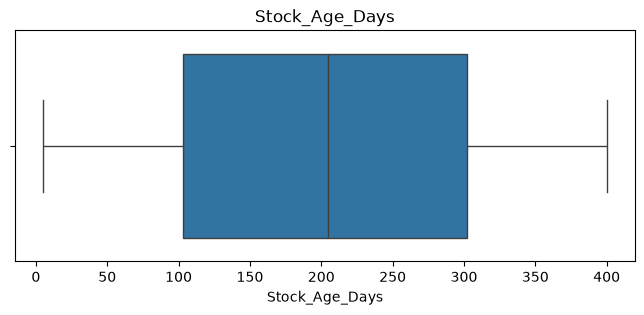

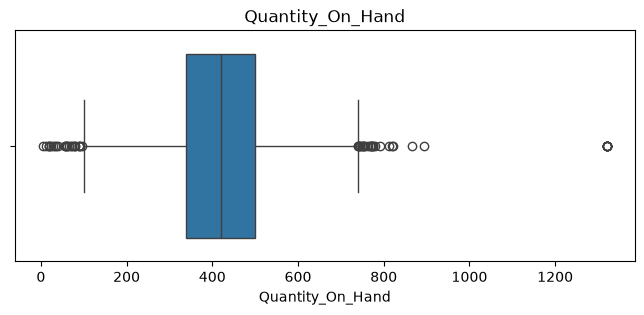

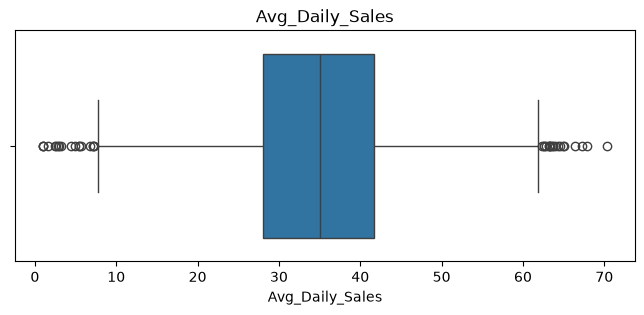

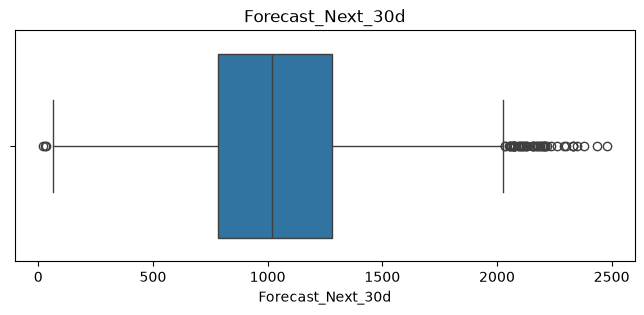

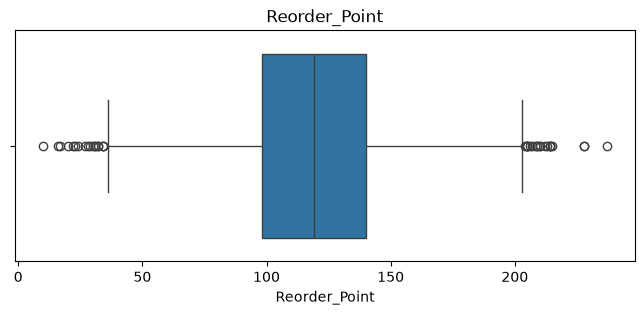

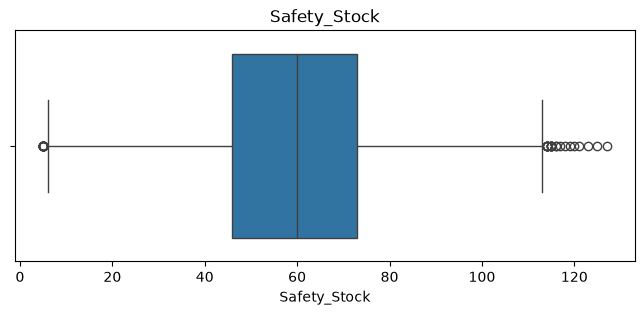

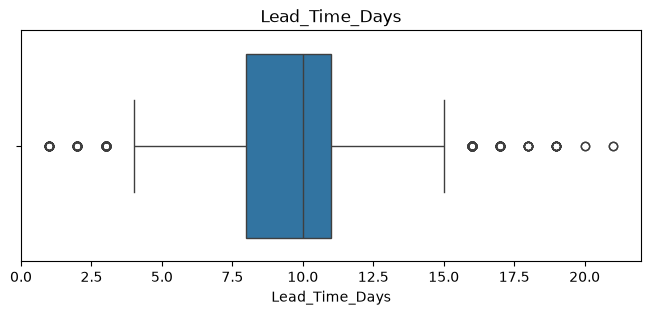

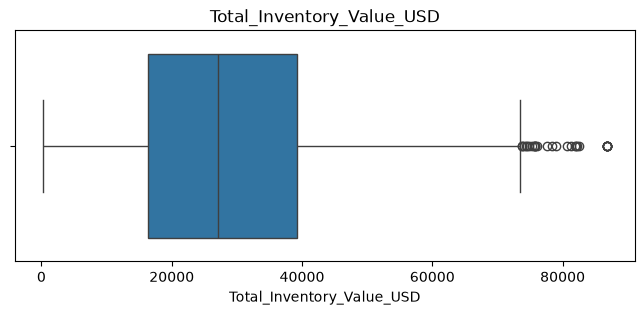

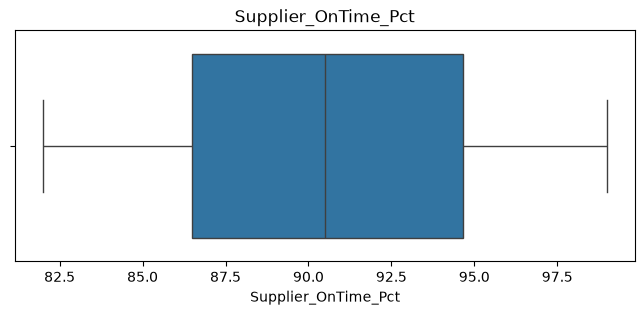

In [20]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## IQR-Based Outlier Analysis

In [21]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Stock_Age_Days: 0 outliers
Quantity_On_Hand: 57 outliers
Avg_Daily_Sales: 37 outliers
Forecast_Next_30d: 54 outliers
Reorder_Point: 39 outliers
Safety_Stock: 49 outliers
Lead_Time_Days: 289 outliers
Total_Inventory_Value_USD: 29 outliers
Supplier_OnTime_Pct: 0 outliers


### Summary

The Interquartile Range (IQR) method was applied to identify potential outliers in numerical variables. Several columns contained observations outside the calculated bounds and were investigated further.

## Outlier Investigation

In [22]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Stock_Age_Days,6700.0,203.440149,114.148062,5.00,103.0000,205.00,302.0000,400.000000
Quantity_On_Hand,6700.0,420.440573,122.075674,5.00,339.0000,421.00,499.0000,1320.229621
Avg_Daily_Sales,6700.0,34.885267,10.028092,1.00,28.0800,34.99,41.7400,70.290000
Forecast_Next_30d,6700.0,1045.197323,363.907782,20.84,784.0650,1018.58,1281.8875,2478.370000
Reorder_Point,6700.0,119.034179,30.196711,10.00,98.0000,119.00,140.0000,237.000000
Safety_Stock,6700.0,59.614030,19.982377,5.00,46.0000,60.00,73.0000,127.000000
Lead_Time_Days,6700.0,9.558806,2.957727,1.00,8.0000,10.00,11.0000,21.000000
Total_Inventory_Value_USD,6700.0,28957.341513,15260.486321,251.06,16341.1525,27060.08,39292.9050,86760.458785
Supplier_OnTime_Pct,6700.0,90.545269,4.811446,82.00,86.4900,90.51,94.6500,98.990000


In [24]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Min Value: {df[col].min()}")
    print(f"Max Value: {df[col].max()}")


Stock_Age_Days
Lower Bound: -195.5
Upper Bound: 600.5
Min Value: 5
Max Value: 400

Quantity_On_Hand
Lower Bound: 99.0
Upper Bound: 739.0
Min Value: 5.0
Max Value: 1320.229621389992

Avg_Daily_Sales
Lower Bound: 7.589999999999993
Upper Bound: 62.230000000000004
Min Value: 1.0
Max Value: 70.29

Forecast_Next_30d
Lower Bound: 37.33125000000041
Upper Bound: 2028.6212499999995
Min Value: 20.84
Max Value: 2478.37

Reorder_Point
Lower Bound: 35.0
Upper Bound: 203.0
Min Value: 10
Max Value: 237

Safety_Stock
Lower Bound: 5.5
Upper Bound: 113.5
Min Value: 5
Max Value: 127

Lead_Time_Days
Lower Bound: 3.5
Upper Bound: 15.5
Min Value: 1.0
Max Value: 21.0

Total_Inventory_Value_USD
Lower Bound: -18086.476249999996
Upper Bound: 73720.53375
Min Value: 251.06
Max Value: 86760.45878547232

Supplier_OnTime_Pct
Lower Bound: 74.24999999999997
Upper Bound: 106.89000000000001
Min Value: 82.0
Max Value: 98.99


### Summary

The identified outliers were investigated using descriptive statistics and business context.

Although several variables contained observations outside the IQR bounds, the values were found to be realistic for an inventory management dataset. Examples include high inventory quantities, large inventory values, long supplier lead times, and elevated forecast demand.

Since no impossible or erroneous values were detected, the outliers were retained and no capping or removal was performed.

In [30]:
df.to_csv(
    "../data/interim/cleaned_day2.csv",
    index=False
)

## Transformation Assessment

The numerical variables were reviewed for potential transformations. Although some variables contained statistical outliers, the values were found to be realistic within the inventory management context.

Since no severe data quality issues or unrealistic distributions were identified, no transformations were applied.

## Conclusion

The data preprocessing stage was completed successfully, and the following actions were performed:

- Removed **12 duplicate records** to ensure unique inventory observations.
- Identified and treated missing values in `Received_Date`, `Forecast_Next_30d`, `Lead_Time_Days`, and `Supplier_OnTime_Pct`.
- Imputed `Forecast_Next_30d` using the relationship between average daily sales and forecast demand.
- Imputed `Lead_Time_Days` and `Supplier_OnTime_Pct` using supplier-wise median values.
- Imputed `Received_Date` using category-wise median dates to preserve realistic inventory timelines.
- Standardized categorical variables by removing unnecessary spaces and validating category consistency.
- Performed outlier detection using the IQR method across all numerical variables.
- Investigated identified outliers using statistical measures and business context.
- Determined that the detected outliers represented valid business observations and therefore retained them.
- Exported the cleaned dataset for subsequent exploratory data analysis.

### Outcome

The dataset is now free from duplicate records and missing values, with consistent categorical data and validated numerical features. It is ready for univariate analysis, bivariate analysis, statistical testing, and feature engineering.